In [3]:
import glob
import mne 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Get evoked data

In [4]:
evokeds_files = sorted(glob.glob('./analysis/looming*-ave.fif'))
del evokeds_files[-1]
print(evokeds_files)
evks = []

for subj in evokeds_files:
    evks.append(mne.read_evokeds(subj, condition=None, verbose=False))

standard_combined = mne.combine_evoked([e[0] for e in evks], weights='nave')
looming_combined = mne.combine_evoked([e[1] for e in evks], weights='nave')
receding_combined = mne.combine_evoked([e[2] for e in evks], weights='nave')
deviant_combined = mne.combine_evoked([e[3] for e in evks], weights='nave')

all_conds = [standard_combined, looming_combined, receding_combined, deviant_combined]

['./analysis\\Looming0010-ave.fif', './analysis\\Looming0011-ave.fif', './analysis\\Looming0014-ave.fif', './analysis\\Looming0015-ave.fif', './analysis\\Looming003-ave.fif', './analysis\\Looming004-ave.fif', './analysis\\Looming006-ave.fif', './analysis\\Looming008-ave.fif', './analysis\\Looming009-ave.fif', './analysis\\looming0016-ave.fif', './analysis\\looming0017-ave.fif', './analysis\\looming0018-ave.fif', './analysis\\looming002-ave.fif', './analysis\\looming005-ave.fif']


#### Rename channels

In [5]:
# Replace all channels with proper channel names instead of numbers
channel_names_old = looming_combined.ch_names
channel_names_new = ['Fp1','Fz','F3','F7','FT9','FC5','FC1','C3','T7','TP9','CP5','CP1','Pz','P3','P7','O1','Oz','O2','P4','P8','TP10','CP6',
                        'CP2','C4','T8','FT10','FC6','FC2','F4','F8','Fp2', 'AF7','AF3','AFz','F1','F5','FT7','FC3','C1','C5','TP7','CP3','P1','P5',
                        'PO7','PO3','POz','PO4','PO8','P6','P2','CPz','CP4','TP8','C6','C2','FC4','FT8','F6','AF8','AF4','F2','FCz', 'Cz']
channel_dict = dict(zip(channel_names_old, channel_names_new))

for cond in all_conds:
    mne.rename_channels(cond.info, mapping=channel_dict)

#### Peak Latency & Amplitude

In [6]:
# Function to print out the channel (ch) containing the peak latency and amplitude within the provided time range 
def print_peak_measures(ch, tmin, tmax, lat, amp):
    print(f'Channel: {ch}')
    print(f'Time Window: {tmin * 1e3:.3f} - {tmax * 1e3:.3f} ms')
    print(f'Peak Latency: {lat * 1e3:.3f} ms')
    print(f'Peak Amplitude: {amp * 1e6:.3f} µV')

In [7]:
looming_Fz = looming_combined.copy().pick('Fz')
receding_Fz = receding_combined.copy().pick('Fz')
deviant_Fz = deviant_combined.copy().pick('Fz')
tmin, tmax = 0.1, 0.3

# Get the peak and latency measure from the selected channel
ch_looming, lat_looming, amp_looming = looming_Fz.get_peak(tmin=tmin, tmax=tmax, mode='neg', return_amplitude=True)
looming_data = looming_Fz.data[0][int(tmin*1000) : int(tmax*1000)]
looming_auc = (np.sum(np.abs(looming_data)))
print('---------------------- Looming ----------------------')
print_peak_measures(ch_looming, tmin, tmax, lat_looming, amp_looming)
print(f'AUC: {looming_auc}')

ch_receding, lat_receding, amp_receding = receding_Fz.get_peak(tmin=tmin, tmax=tmax, mode='neg', return_amplitude=True)
receding_data = receding_Fz.data[0][int(tmin*1000) : int(tmax*1000)]
receding_auc = (np.sum(np.abs(receding_data)))
print('---------------------- Receding ----------------------')
print_peak_measures(ch_receding, tmin, tmax, lat_receding, amp_receding)
print(f'AUC: {receding_auc}')

ch_deviant, lat_deviant, amp_deviant = deviant_Fz.get_peak(tmin=tmin, tmax=tmax, mode='neg', return_amplitude=True)
deviant_data = deviant_Fz.data[0][int(tmin*1000) : int(tmax*1000)]
deviant_auc = (np.sum(np.abs(deviant_data)))
print('---------------------- Deviant ----------------------')
print_peak_measures(ch_deviant, tmin, tmax, lat_deviant, amp_deviant)
print(f'AUC: {deviant_auc}')

---------------------- Looming ----------------------
Channel: Fz
Time Window: 100.000 - 300.000 ms
Peak Latency: 250.000 ms
Peak Amplitude: -1.178 µV
AUC: 2.6957058001818226e-05
---------------------- Receding ----------------------
Channel: Fz
Time Window: 100.000 - 300.000 ms
Peak Latency: 248.000 ms
Peak Amplitude: -0.675 µV
AUC: 6.261630948766938e-05
---------------------- Deviant ----------------------
Channel: Fz
Time Window: 100.000 - 300.000 ms
Peak Latency: 247.000 ms
Peak Amplitude: -0.753 µV
AUC: 3.0344126982170085e-05


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


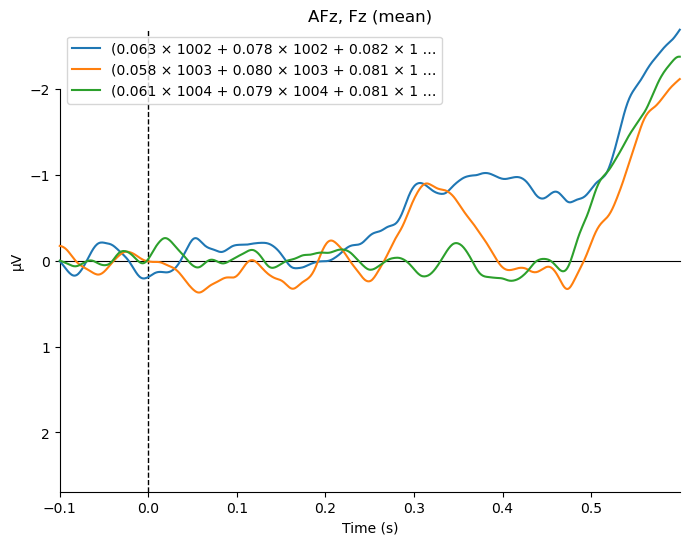

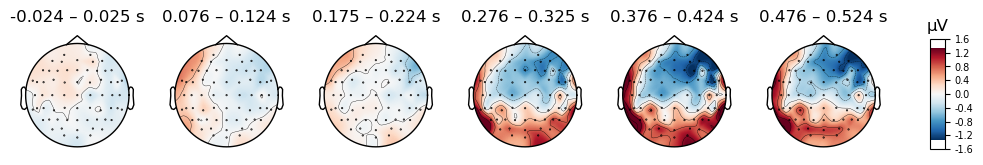

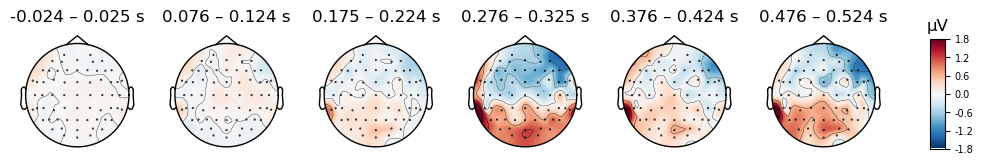

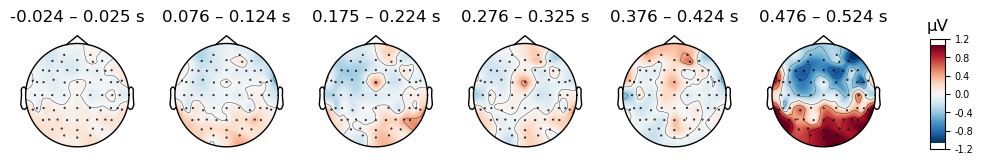

In [20]:
diff_loom = mne.combine_evoked([looming_combined, standard_combined],  weights=[1, -1])
diff_rec = mne.combine_evoked([receding_combined, standard_combined],  weights=[1, -1])
diff_dev = mne.combine_evoked([deviant_combined, standard_combined],  weights=[1, -1])

mne.viz.plot_compare_evokeds([diff_loom, diff_rec, diff_dev], picks=['AFz', 'Fz'], combine='mean', ci=0.95, legend=True, truncate_xaxis=False, invert_y=True)

# Specify times to plot at, as [min],[max],[stepsize]
times_loom = np.arange(0, diff_loom.tmax, 0.1)
times_rec = np.arange(0, diff_rec.tmax, 0.1)
times_dev = np.arange(0, diff_dev.tmax, 0.1)
diff_loom.plot_topomap(times=times_loom, average=0.050);
diff_rec.plot_topomap(times=times_rec, average=0.050);
diff_dev.plot_topomap(times=times_dev, average=0.050);

Reading g:\Utilisateurs\rudradeep.guha\Documents\looming\analysis\Looming004-epo.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 64) active
    Found the data of interest:
        t =    -100.00 ...     600.00 ms
        0 CTF compensation matrices available
Not setting metadata
1999 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
1999
Not setting metadata
1999 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1999 matching events found
No baseline correction applied
0 projection items activated


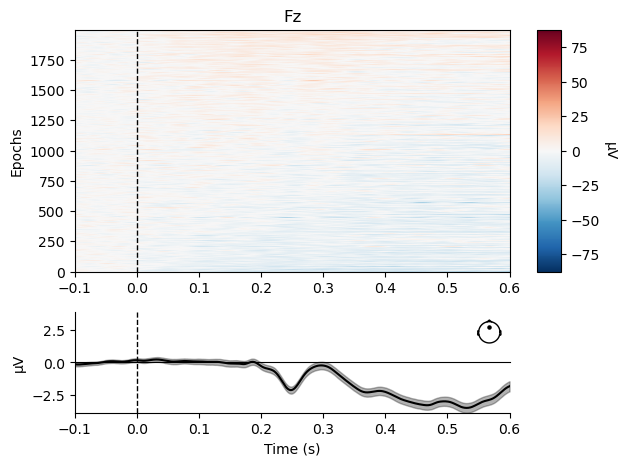

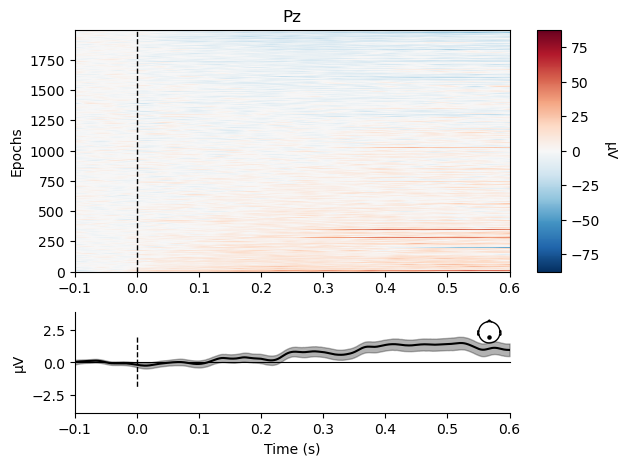

[<Figure size 640x480 with 4 Axes>, <Figure size 640x480 with 4 Axes>]

In [9]:
# and order with spectral reordering
# If you don't have scikit-learn installed set order_func to None
from sklearn.manifold import spectral_embedding  # noqa
from sklearn.metrics.pairwise import rbf_kernel   # noqa


epochs = mne.read_epochs('./analysis/Looming004-epo.fif')
print(len(epochs))

def order_func(times, data):
    this_data = data[:, (times > 0.0) & (times < 0.350)]
    this_data /= np.sqrt(np.sum(this_data ** 2, axis=1))[:, np.newaxis]
    return np.argsort(spectral_embedding(rbf_kernel(this_data, gamma=1.),
                      n_components=1, random_state=0).ravel())


good_pick = 'Fz'  # channel with a clear evoked response
bad_pick = 'Pz'  # channel with no evoked response

# We'll also plot a sample time onset for each trial
plt_times = np.linspace(.15, .25, len(epochs))

plt.close('all')
mne.viz.plot_epochs_image(epochs, [good_pick, bad_pick], sigma=.5,
                          order=order_func, 
                          show=True)